In [3]:
"""
Model Evaluation & Analysis

Load the trained model and evaluate on test set.
"""

import sys
sys.path.append('..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.models.cnn_model import create_model
from src.models.metrics import MetricsCalculator
from src.data.dataset import HAM10000Dataset
from src.data.augmentations import get_valid_transforms
from src.data.dataloader import get_dataloader

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


In [4]:
# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}\n")

# Load model
model = create_model(
    num_classes=7,
    pretrained=False,  # We're loading trained weights
    device=device
)

# Load checkpoint
checkpoint_path = '../models/best_model.pth'
# In PyTorch >=2.6, weights_only defaults to True which breaks older checkpoints.
# Set weights_only=False here since this checkpoint was created locally and is trusted.
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
print(f"   Best val F1: {checkpoint['best_val_f1']:.4f}")
print(f"   Best val loss: {checkpoint['best_val_loss']:.4f}")

Using device: mps

✅ Model initialized:
   Backbone: EfficientNet-B3 (random init)
   Classifier: 1536 → 7
   Dropout: 0.3
   Backbone frozen: False

📊 Model Parameters:
   Total:     10,706,992
   Trainable: 10,706,992
   Frozen:    0
   Device:    mps
✅ Loaded best model from epoch 22
   Best val F1: 0.7155
   Best val loss: 0.2612


In [5]:
# Load test set
test_dataset = HAM10000Dataset(
    metadata_path='../data/metadata.csv',
    data_dir='../data/processed',
    split='test',
    transform=get_valid_transforms(image_size=224)
)

test_loader = get_dataloader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    use_weighted_sampling=False,
    num_workers=2
)

print(f"✅ Test set loaded: {len(test_dataset)} samples")

✅ Loaded 1002 test samples

📊 Class distribution (test):
   nv     (Melanocytic Nevi         ):  671 (66.97%)
   mel    (Melanoma                 ):  112 (11.18%)
   bkl    (Benign Keratosis         ):  110 (10.98%)
   bcc    (Basal Cell Carcinoma     ):   52 ( 5.19%)
   akiec  (Actinic Keratoses        ):   32 ( 3.19%)
   vasc   (Vascular Lesions         ):   14 ( 1.40%)
   df     (Dermatofibroma           ):   11 ( 1.10%)
✅ Test set loaded: 1002 samples


In [6]:
# Run inference on test set
print("Running inference on test set...\n")

metrics_calc = MetricsCalculator(
    num_classes=7,
    class_names={i: HAM10000Dataset.FULL_NAMES[HAM10000Dataset.IDX_TO_CLASS[i]] 
                for i in range(7)}
)

all_predictions = []
all_targets = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        metrics_calc.update(preds, labels, probs)
        
        all_predictions.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Compute metrics
test_metrics = metrics_calc.compute()

# Print summary
metrics_calc.print_summary()

Running inference on test set...


📊 METRICS SUMMARY

🎯 Overall Performance:
   Accuracy:          0.6647
   Macro F1:          0.6892
   Weighted F1:       0.6980
   Macro AUC:         0.9577
   Weighted AUC:      0.9440

🎯 CRITICAL: Melanoma Detection:
   Sensitivity (Recall): 0.8571
   → This is our most important metric!

📋 Per-Class Performance:
   Actinic Keratoses: P=0.600 R=0.750 F1=0.667
   Basal Cell Carcinoma: P=0.682 R=0.865 F1=0.763
   Benign Keratosis: P=0.582 R=0.709 F1=0.639
   Dermatofibroma: P=0.688 R=1.000 F1=0.815
   Melanoma: P=0.296 R=0.857 F1=0.440
   Melanocytic Nevi: P=0.997 R=0.593 F1=0.744
   Vascular Lesions: P=0.609 R=1.000 F1=0.757


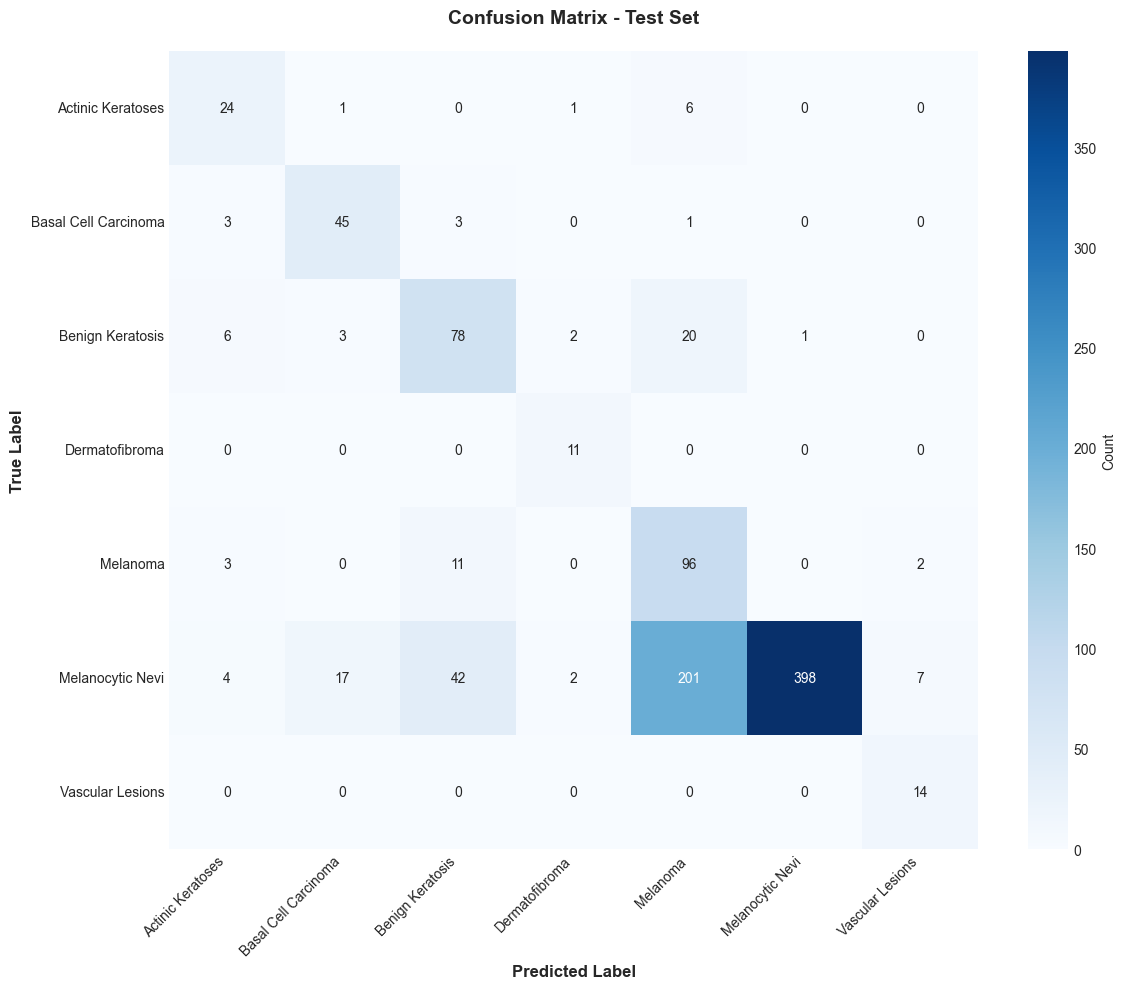

💾 Confusion matrix saved to logs/confusion_matrix.png


<Figure size 640x480 with 0 Axes>

In [7]:
# Get confusion matrix
cm = metrics_calc.get_confusion_matrix()

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

class_labels = [HAM10000Dataset.FULL_NAMES[HAM10000Dataset.IDX_TO_CLASS[i]] 
                for i in range(7)]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=ax,
    cbar_kws={'label': 'Count'}
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save
plt.savefig('../logs/confusion_matrix.png', dpi=300, bbox_inches='tight')
print("💾 Confusion matrix saved to logs/confusion_matrix.png")

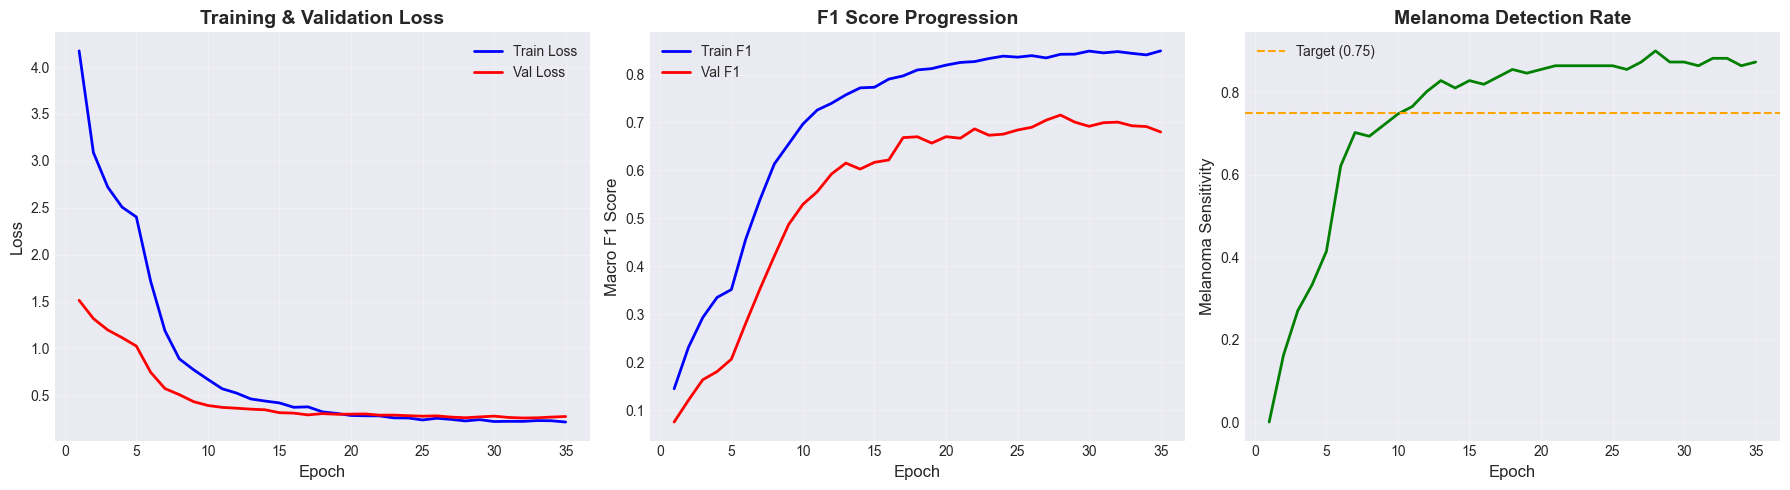

💾 Training curves saved to logs/training_curves.png


<Figure size 640x480 with 0 Axes>

In [8]:
# Load training history
import json

with open('../logs/training_history.json', 'r') as f:
    history = json.load(f)

train_losses = history['train_losses']
val_losses = history['val_losses']

# Extract F1 scores
train_f1 = [m['macro_f1'] for m in history['train_metrics']]
val_f1 = [m['macro_f1'] for m in history['val_metrics']]

# Extract melanoma sensitivity
melanoma_sensitivity = [m['melanoma_sensitivity'] for m in history['val_metrics']]

epochs = range(1, len(train_losses) + 1)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 Score
axes[1].plot(epochs, train_f1, 'b-', label='Train F1', linewidth=2)
axes[1].plot(epochs, val_f1, 'r-', label='Val F1', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Macro F1 Score', fontsize=12)
axes[1].set_title('F1 Score Progression', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Melanoma Sensitivity
axes[2].plot(epochs, melanoma_sensitivity, 'g-', linewidth=2)
axes[2].axhline(y=0.75, color='orange', linestyle='--', label='Target (0.75)')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Melanoma Sensitivity', fontsize=12)
axes[2].set_title('Melanoma Detection Rate', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save
plt.savefig('../logs/training_curves.png', dpi=300, bbox_inches='tight')
print("💾 Training curves saved to logs/training_curves.png")

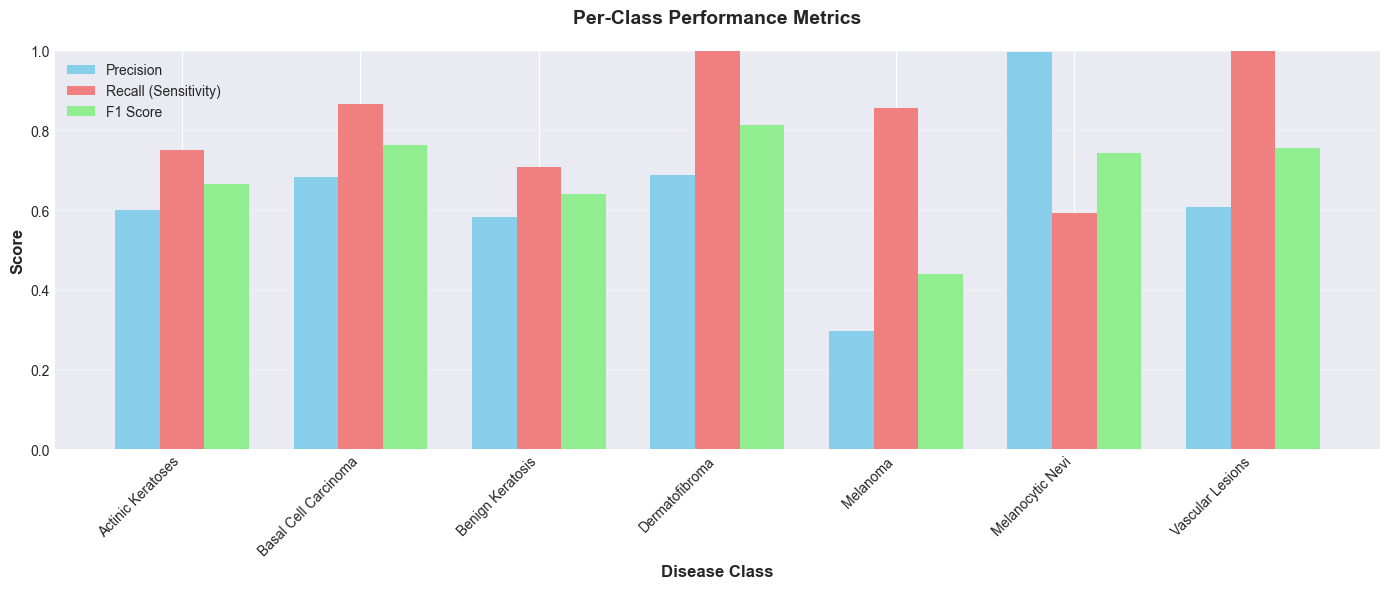

💾 Per-class metrics saved to logs/per_class_metrics.png

📊 Detailed Per-Class Metrics:
               Class  Precision   Recall       F1
   Actinic Keratoses   0.600000 0.750000 0.666667
Basal Cell Carcinoma   0.681818 0.865385 0.762712
    Benign Keratosis   0.582090 0.709091 0.639344
      Dermatofibroma   0.687500 1.000000 0.814815
            Melanoma   0.296296 0.857143 0.440367
    Melanocytic Nevi   0.997494 0.593145 0.743925
    Vascular Lesions   0.608696 1.000000 0.756757


<Figure size 640x480 with 0 Axes>

In [9]:
# Extract per-class metrics
class_metrics = []

for i in range(7):
    class_name = HAM10000Dataset.FULL_NAMES[HAM10000Dataset.IDX_TO_CLASS[i]]
    
    precision = test_metrics[f'{class_name}_precision']
    recall = test_metrics[f'{class_name}_recall']
    f1 = test_metrics[f'{class_name}_f1']
    
    class_metrics.append({
        'Class': class_name,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

# Create DataFrame
df_metrics = pd.DataFrame(class_metrics)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_metrics))
width = 0.25

bars1 = ax.bar(x - width, df_metrics['Precision'], width, label='Precision', color='skyblue')
bars2 = ax.bar(x, df_metrics['Recall'], width, label='Recall (Sensitivity)', color='lightcoral')
bars3 = ax.bar(x + width, df_metrics['F1'], width, label='F1 Score', color='lightgreen')

ax.set_xlabel('Disease Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Class'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

# Save
plt.savefig('../logs/per_class_metrics.png', dpi=300, bbox_inches='tight')
print("💾 Per-class metrics saved to logs/per_class_metrics.png")

# Print table
print("\n📊 Detailed Per-Class Metrics:")
print(df_metrics.to_string(index=False))

In [10]:
# Check if we have AUC scores
if 'macro_auc' in test_metrics:
    print(f"Overall AUC Scores:")
    print(f"  Macro AUC: {test_metrics['macro_auc']:.4f}")
    print(f"  Weighted AUC: {test_metrics['weighted_auc']:.4f}")
    
    print(f"\nPer-Class AUC:")
    for i in range(7):
        class_name = HAM10000Dataset.FULL_NAMES[HAM10000Dataset.IDX_TO_CLASS[i]]
        auc_key = f'{class_name}_auc'
        if auc_key in test_metrics:
            print(f"  {class_name}: {test_metrics[auc_key]:.4f}")

Overall AUC Scores:
  Macro AUC: 0.9577
  Weighted AUC: 0.9440

Per-Class AUC:
  Actinic Keratoses: 0.9644
  Basal Cell Carcinoma: 0.9909
  Benign Keratosis: 0.9235
  Dermatofibroma: 1.0000
  Melanoma: 0.8748
  Melanocytic Nevi: 0.9522
  Vascular Lesions: 0.9981


In [11]:
# Save test metrics to file
test_results = {
    'test_metrics': {k: float(v) if isinstance(v, (int, float, np.number)) else v 
                     for k, v in test_metrics.items()},
    'confusion_matrix': cm.tolist(),
    'class_names': [HAM10000Dataset.FULL_NAMES[HAM10000Dataset.IDX_TO_CLASS[i]] 
                    for i in range(7)]
}

import json
with open('../logs/test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)

print("✅ Test results saved to logs/test_results.json")

✅ Test results saved to logs/test_results.json
